## Notebook Overview — Source-Pair Analysis

**Purpose**

* Evaluate model generalization across different dataset combinations by analyzing performance on real vs AI source pairings
* Assess sensitivity of the trained model to variations in dataset origin
* Identify strengths and weaknesses in cross-source robustness using the finalized 26-feature DIP representation

**Inputs**

* `train_feature_vectors_normalized.csv` — normalized training feature vectors (N × 26 features)
* `test_feature_vectors_normalized.csv` — normalized testing feature vectors (N × 26 features)

**Execution Model**

* Load normalized feature vectors and validate dataset structure
* Define source-pair experiments across all dataset permutations (3 real × 3 AI = 9 combinations)
* Construct balanced datasets for each source pair
* Train a classifier using the fixed tuned MLP configuration for each pairing
* Evaluate model performance using standard metrics and ROC curves
* Aggregate results and compare performance across all source pairs
* Visualize ROC curves to analyze classification behavior across thresholds

**Outputs**

* Source-pair performance metrics (Accuracy, Precision, Recall, F1, ROC AUC)
* ROC curve data (FPR, TPR, thresholds) for all source-pair models
* Comparative results table sorted by ROC AUC
* ROC curve plot showing performance across all source pairs

**Expected Behavior**

* Performance varies across source pairs, reflecting dataset-specific characteristics
* Some source combinations exhibit stronger separability between real and AI images
* Differences highlight sensitivity to underlying data distributions
* ROC curves provide deeper insight into classification performance beyond single metrics

---
---

### 🔷 Step 1 — Startup — Environment, Paths, and Verification

This step initializes the notebook environment and prepares all required dependencies for execution. It ensures that the project repository is available, required libraries are loaded, and input data files are accessible before proceeding with analysis.

* Imports all necessary Python libraries for data handling and system operations
* Configures verbosity and optional warning suppression for cleaner output
* Clones the project repository if not already present in the runtime environment
* Adds the project `src/` directory to the Python path for module access
* Loads centralized configuration settings from `project_config.py`
* Verifies the presence of required normalized feature vector CSV files
* Displays environment and path information when verbose mode is enabled

This step establishes a consistent and validated starting point for all subsequent source-pair analysis operations.


In [1]:
# ============================================
# Step 1: Startup — Environment and Verification
# ============================================

# ============================================
# USER CONFIGURATION — EDIT THIS SECTION ONLY
# ============================================

VERBOSE = True   # User toggle (True or False)

# ============================================
# END USER CONFIGURATION
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import os
import sys
import warnings
from pathlib import Path

# Suppress warnings for cleaner output
if not VERBOSE:
    warnings.filterwarnings("ignore")

# -------------------------------------------------
# Clone GitHub repository if needed
# -------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone --quiet {REPO_URL} {REPO_DIR}")
else:
    print("Repository already available.")

# -------------------------------------------------
# Add src directory to Python path
# -------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# -------------------------------------------------
# Import shared project configuration
# -------------------------------------------------
from project_config import (
    TRAIN_NORMALIZED_PATH,
    TEST_NORMALIZED_PATH,
    RESULTS_METADATA_DIR,
    MODELS_METADATA_DIR,
    NUM_FEATURES,
    AI_SOURCES,
    REAL_SOURCES,
    SOURCE_FOLDER_NAMES,
    DATASET_CODES,
    AI_LABEL,
    REAL_LABEL,
    RANDOM_SEED,
)

# -------------------------------------------------
# Convert configured paths to Path objects
# -------------------------------------------------
TRAIN_NORMALIZED_FILE = Path(TRAIN_NORMALIZED_PATH)
TEST_NORMALIZED_FILE = Path(TEST_NORMALIZED_PATH)

RESULTS_DIR = Path(RESULTS_METADATA_DIR)
MODELS_DIR = Path(MODELS_METADATA_DIR)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Verify required input files
# -------------------------------------------------
print("\nVerifying required inputs...\n")

required_files = [
    TRAIN_NORMALIZED_FILE,
    TEST_NORMALIZED_FILE,
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required file: {file_path}")

print("Required input files are present.")

# -------------------------------------------------
# Optional verbose display of configuration values
# -------------------------------------------------
if VERBOSE:
    print(f"\nTrain feature file: {TRAIN_NORMALIZED_FILE}")
    print(f"Test feature file:  {TEST_NORMALIZED_FILE}")
    print(f"Results directory:  {RESULTS_DIR}")
    print(f"Models directory:   {MODELS_DIR}")
    print(f"Expected features:  {NUM_FEATURES}")
    print(f"Real sources:       {REAL_SOURCES}")
    print(f"AI sources:         {AI_SOURCES}")

print("\nStartup complete.")



Cloning repository...

Verifying required inputs...

Required input files are present.

Train feature file: /content/dip-ai-image-detection/metadata/vectors/train_feature_vectors_normalized.csv
Test feature file:  /content/dip-ai-image-detection/metadata/vectors/test_feature_vectors_normalized.csv
Results directory:  /content/dip-ai-image-detection/metadata/results
Models directory:   /content/dip-ai-image-detection/metadata/models
Expected features:  26
Real sources:       ['imagenet', 'coco', 'openimages']
AI sources:         ['diffusiondb', 'sdxl', 'midjourney']

Startup complete.


### 🔷 Step 2 — Load Feature Vectors and Validate Structure

This step loads the normalized feature vector datasets and verifies that they conform to the finalized 26-feature project configuration. It ensures required metadata is present, feature columns are correctly identified, and training and test datasets are consistent before proceeding to source-pair analysis.

* Loads normalized training and test feature vector CSV files
* Verifies required metadata columns are present (class_label, source_dataset)
* Identifies feature columns by excluding metadata fields
* Confirms feature count matches the expected 26-feature configuration
* Ensures training and test datasets have identical feature structure
* Displays dataset statistics and distributions when verbose mode is enabled

---

In [2]:
# ============================================
# Step 2: Load Feature Vectors and Validate Structure
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import pandas as pd

# -------------------------------------------------
# Convert configured paths to Path objects
# -------------------------------------------------
TRAIN_NORMALIZED_FILE = Path(TRAIN_NORMALIZED_PATH)
TEST_NORMALIZED_FILE  = Path(TEST_NORMALIZED_PATH)

# -------------------------------------------------
# Verify required input files
# -------------------------------------------------
print("Verifying feature vector input files...")

required_files = [
    TRAIN_NORMALIZED_FILE,
    TEST_NORMALIZED_FILE,
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required file: {file_path}")

print("Required feature vector files are present.")

# -------------------------------------------------
# Load normalized feature vector CSV files
# -------------------------------------------------
train_df = pd.read_csv(TRAIN_NORMALIZED_FILE)
test_df  = pd.read_csv(TEST_NORMALIZED_FILE)

print("Feature vector files loaded.")

# -------------------------------------------------
# Define required metadata columns
# -------------------------------------------------
required_columns = [
    "filename",
    "class_label",
    "source_dataset",
    "subset",
]

# -------------------------------------------------
# Verify required metadata columns
# -------------------------------------------------
for column in required_columns:
    if column not in train_df.columns:
        raise ValueError(f"Missing required training column: {column}")

    if column not in test_df.columns:
        raise ValueError(f"Missing required test column: {column}")

print("Required metadata columns verified.")

# -------------------------------------------------
# Identify metadata columns
# -------------------------------------------------
metadata_columns = required_columns.copy()

# -------------------------------------------------
# Identify feature columns
# -------------------------------------------------
feature_columns = [
    column for column in train_df.columns
    if column not in metadata_columns
]

# -------------------------------------------------
# Verify feature count matches project configuration
# -------------------------------------------------
if len(feature_columns) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, "
        f"but found {len(feature_columns)}."
    )

print(f"Feature column count verified: {len(feature_columns)} features.")

# -------------------------------------------------
# Verify matching train/test feature columns
# -------------------------------------------------
test_feature_columns = [
    column for column in test_df.columns
    if column not in metadata_columns
]

if feature_columns != test_feature_columns:
    raise ValueError("Training and test feature columns do not match.")

print("Training and test feature columns verified.")

# -------------------------------------------------
# Optional verbose display of dataset structure
# -------------------------------------------------
if VERBOSE:
    print(f"Training dataset shape: {train_df.shape}")
    print(f"Test dataset shape:     {test_df.shape}")
    print("Training label counts:")
    print(train_df["class_label"].value_counts())
    print("Test label counts:")
    print(test_df["class_label"].value_counts())
    print("Training source counts:")
    print(train_df["source_dataset"].value_counts())
    print("Test source counts:")
    print(test_df["source_dataset"].value_counts())

print("\nFeature vector loading and validation complete.")



Verifying feature vector input files...
Required feature vector files are present.
Feature vector files loaded.
Required metadata columns verified.
Feature column count verified: 26 features.
Training and test feature columns verified.
Training dataset shape: (14400, 30)
Test dataset shape:     (3600, 30)
Training label counts:
class_label
rl    7200
ai    7200
Name: count, dtype: int64
Test label counts:
class_label
rl    1800
ai    1800
Name: count, dtype: int64
Training source counts:
source_dataset
ImageNet_1K_256       2400
MS_COCO_2017          2400
Midjourney            2400
OpenImages            2400
SDXL_Generated_10K    2400
DiffusionDB           2400
Name: count, dtype: int64
Test source counts:
source_dataset
MS_COCO_2017          600
SDXL_Generated_10K    600
DiffusionDB           600
OpenImages            600
Midjourney            600
ImageNet_1K_256       600
Name: count, dtype: int64

Feature vector loading and validation complete.


### 🔷 Step 3 — Define Source-Pair Experiments

This step defines the real-vs-AI source-pair experiments used for source-pair analysis. It uses the project configuration to construct all real and AI source combinations and creates a reusable experiment table for downstream filtering, training, and evaluation.

* Uses configured real and AI source lists from `project_config.py`
* Builds all source-pair combinations across 3 real sources and 3 AI sources
* Creates a structured experiment table using logical source names
* Verifies that all mapped source names are present in the dataset
* Displays the experiment table when verbose mode is enabled

---

In [3]:
# ============================================
# Step 3: Define Source-Pair Experiments
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
from itertools import product

# -------------------------------------------------
# Define column names used for analysis
# -------------------------------------------------
LABEL_COLUMN = "class_label"
SOURCE_COLUMN = "source_dataset"

# -------------------------------------------------
# Build source-pair experiment definitions
# -------------------------------------------------
source_pair_records = []

for real_source, ai_source in product(REAL_SOURCES, AI_SOURCES):

    experiment_id = f"{DATASET_CODES[real_source]}_{DATASET_CODES[ai_source]}"

    source_pair_records.append({
        "experiment_id": experiment_id,
        "real_source": real_source,
        "ai_source": ai_source,
        "description": f"{real_source} vs {ai_source}",
    })

# -------------------------------------------------
# Create source-pair experiment table
# -------------------------------------------------
source_pair_df = pd.DataFrame(source_pair_records)

# -------------------------------------------------
# Verify configured sources exist in dataset
# -------------------------------------------------
available_train_sources = set(train_df[SOURCE_COLUMN].unique())
available_test_sources = set(test_df[SOURCE_COLUMN].unique())

configured_sources = set(
    SOURCE_FOLDER_NAMES[src] for src in REAL_SOURCES + AI_SOURCES
)

missing_train_sources = sorted(configured_sources - available_train_sources)
missing_test_sources = sorted(configured_sources - available_test_sources)

if missing_train_sources:
    raise ValueError(
        f"Configured sources missing from training data: {missing_train_sources}"
    )

if missing_test_sources:
    raise ValueError(
        f"Configured sources missing from test data: {missing_test_sources}"
    )

print("Configured source-pair experiments verified.")

# -------------------------------------------------
# Optional verbose display of source-pair table
# -------------------------------------------------
if VERBOSE:
    print()
    print(f"Number of source-pair experiments: {len(source_pair_df)}")
    display(source_pair_df)

print("Source-pair experiment definition complete.")



Configured source-pair experiments verified.

Number of source-pair experiments: 9


,experiment_id,real_source,ai_source,description
0,imgn_diff,imagenet,diffusiondb,imagenet vs diffusiondb
1,imgn_sdxl,imagenet,sdxl,imagenet vs sdxl
2,imgn_midj,imagenet,midjourney,imagenet vs midjourney
3,coco_diff,coco,diffusiondb,coco vs diffusiondb
4,coco_sdxl,coco,sdxl,coco vs sdxl
5,coco_midj,coco,midjourney,coco vs midjourney
6,open_diff,openimages,diffusiondb,openimages vs diffusiondb
7,open_sdxl,openimages,sdxl,openimages vs sdxl
8,open_midj,openimages,midjourney,openimages vs midjourney


Source-pair experiment definition complete.


### 🔷 Step 4 — Build Balanced Source-Pair Datasets

This step constructs balanced training and test datasets for each source-pair experiment. For each real-vs-AI pairing, it filters the normalized feature vectors by class and source, verifies that both classes are present, and stores the resulting datasets for model training and evaluation.

* Iterates through the source-pair experiment table
* Maps logical source names to CSV source names using `SOURCE_FOLDER_NAMES`
* Filters training and test data for each real-vs-AI pair
* Confirms that each dataset contains both classes
* Stores balanced datasets for later training and evaluation
* Displays dataset sizes when verbose mode is enabled


---

In [4]:
# ============================================
# Step 4: Build Balanced Source-Pair Datasets
# ============================================

# -------------------------------------------------
# Initialize source-pair dataset storage
# -------------------------------------------------
source_pair_datasets = {}
source_pair_counts = []

# -------------------------------------------------
# Build filtered datasets for each source pair
# -------------------------------------------------
for _, row in source_pair_df.iterrows():

    experiment_id = row["experiment_id"]
    real_source = row["real_source"]
    ai_source = row["ai_source"]

    real_dataset_name = SOURCE_FOLDER_NAMES[real_source]
    ai_dataset_name = SOURCE_FOLDER_NAMES[ai_source]

    # -------------------------------------------------
    # Filter training data
    # -------------------------------------------------
    train_real_df = train_df[
        (train_df[LABEL_COLUMN] == REAL_LABEL)
        & (train_df[SOURCE_COLUMN] == real_dataset_name)
    ]

    train_ai_df = train_df[
        (train_df[LABEL_COLUMN] == AI_LABEL)
        & (train_df[SOURCE_COLUMN] == ai_dataset_name)
    ]

    # -------------------------------------------------
    # Filter test data
    # -------------------------------------------------
    test_real_df = test_df[
        (test_df[LABEL_COLUMN] == REAL_LABEL)
        & (test_df[SOURCE_COLUMN] == real_dataset_name)
    ]

    test_ai_df = test_df[
        (test_df[LABEL_COLUMN] == AI_LABEL)
        & (test_df[SOURCE_COLUMN] == ai_dataset_name)
    ]

    # -------------------------------------------------
    # Verify subsets are non-empty
    # -------------------------------------------------
    if train_real_df.empty:
        raise ValueError(f"No training real samples found for {experiment_id}")

    if train_ai_df.empty:
        raise ValueError(f"No training AI samples found for {experiment_id}")

    if test_real_df.empty:
        raise ValueError(f"No test real samples found for {experiment_id}")

    if test_ai_df.empty:
        raise ValueError(f"No test AI samples found for {experiment_id}")

    # -------------------------------------------------
    # Construct datasets
    # -------------------------------------------------
    train_pair_df = pd.concat([train_real_df, train_ai_df]).reset_index(drop=True)
    test_pair_df  = pd.concat([test_real_df, test_ai_df]).reset_index(drop=True)

    # -------------------------------------------------
    # Store datasets
    # -------------------------------------------------
    source_pair_datasets[experiment_id] = {
        "train": train_pair_df,
        "test": test_pair_df,
    }

    # -------------------------------------------------
    # Store dataset counts
    # -------------------------------------------------
    source_pair_counts.append({
        "experiment_id": experiment_id,
        "train_real": len(train_real_df),
        "train_ai": len(train_ai_df),
        "test_real": len(test_real_df),
        "test_ai": len(test_ai_df),
    })

# -------------------------------------------------
# Create count summary table
# -------------------------------------------------
source_pair_counts_df = pd.DataFrame(source_pair_counts)

# -------------------------------------------------
# Verify class balance
# -------------------------------------------------
for _, row in source_pair_counts_df.iterrows():

    if row["train_real"] != row["train_ai"]:
        raise ValueError(f"Training data is not balanced for {row['experiment_id']}")

    if row["test_real"] != row["test_ai"]:
        raise ValueError(f"Test data is not balanced for {row['experiment_id']}")

print("Balanced source-pair datasets created.")

# -------------------------------------------------
# Optional verbose display
# -------------------------------------------------
if VERBOSE:
    print()
    display(source_pair_counts_df)

print("Source-pair dataset construction complete.")



Balanced source-pair datasets created.



,experiment_id,train_real,train_ai,test_real,test_ai
0,imgn_diff,2400,2400,600,600
1,imgn_sdxl,2400,2400,600,600
2,imgn_midj,2400,2400,600,600
3,coco_diff,2400,2400,600,600
4,coco_sdxl,2400,2400,600,600
5,coco_midj,2400,2400,600,600
6,open_diff,2400,2400,600,600
7,open_sdxl,2400,2400,600,600
8,open_midj,2400,2400,600,600


Source-pair dataset construction complete.


### 🔷 Step 5 — Train Source-Pair Models

This step trains one classifier for each balanced source-pair dataset. Each experiment uses the same tuned MLP configuration so that performance differences reflect source-pair behavior rather than changes in model design.

* Loads the tuned MLP configuration
* Trains one model for each source-pair experiment
* Uses the same 26-feature input columns for all models
* Encodes class labels consistently across all experiments
* Stores trained models for later evaluation
* Displays training progress when verbose mode is enabled

---

In [5]:
# ============================================
# Step 5: Train Source-Pair Models
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import json
import warnings

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import ConvergenceWarning

# -------------------------------------------------
# Import tuned model configuration path
# -------------------------------------------------
from project_config import BEST_MLP_MODEL_CONFIG_PATH

# -------------------------------------------------
# Convert configured path to Path object
# -------------------------------------------------
BEST_MLP_CONFIG_FILE = Path(BEST_MLP_MODEL_CONFIG_PATH)

# -------------------------------------------------
# Verify tuned model configuration exists
# -------------------------------------------------
if not BEST_MLP_CONFIG_FILE.exists():
    raise FileNotFoundError(f"Missing tuned MLP config file: {BEST_MLP_CONFIG_FILE}")

print("Tuned MLP configuration file found.")

# -------------------------------------------------
# Load tuned MLP configuration
# -------------------------------------------------
with open(BEST_MLP_CONFIG_FILE, "r") as f:
    best_mlp_config = json.load(f)

print("Tuned MLP configuration loaded.")

# -------------------------------------------------
# Extract valid MLPClassifier parameters
# -------------------------------------------------
valid_mlp_params = MLPClassifier().get_params().keys()

mlp_params = {
    key: value
    for key, value in best_mlp_config.items()
    if key in valid_mlp_params
}

# -------------------------------------------------
# Convert hidden layer configuration if needed
# -------------------------------------------------
if "hidden_layer_sizes" in mlp_params:
    mlp_params["hidden_layer_sizes"] = tuple(mlp_params["hidden_layer_sizes"])

# -------------------------------------------------
# Enforce reproducibility
# -------------------------------------------------
mlp_params["random_state"] = RANDOM_SEED

# -------------------------------------------------
# Initialize model storage
# -------------------------------------------------
source_pair_models = {}

# -------------------------------------------------
# Train one model for each source-pair dataset
# -------------------------------------------------
warnings.filterwarnings("ignore", category=ConvergenceWarning)

for experiment_id, dataset_dict in source_pair_datasets.items():

    if VERBOSE:
        print(f"Training model for {experiment_id}...")

    train_pair_df = dataset_dict["train"]

    X_train = train_pair_df[feature_columns]
    y_train = train_pair_df[LABEL_COLUMN]

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)

    model = MLPClassifier(**mlp_params)
    model.fit(X_train, y_train_encoded)

    source_pair_models[experiment_id] = {
        "model": model,
        "label_encoder": label_encoder,
    }

print("Source-pair model training complete.")
print(f"Number of trained models: {len(source_pair_models)}")



Tuned MLP configuration file found.
Tuned MLP configuration loaded.
Training model for imgn_diff...
Training model for imgn_sdxl...
Training model for imgn_midj...
Training model for coco_diff...
Training model for coco_sdxl...
Training model for coco_midj...
Training model for open_diff...
Training model for open_sdxl...
Training model for open_midj...
Source-pair model training complete.
Number of trained models: 9


In [14]:
# ============================================
# Step 5B: Train Combined Real-vs-AI Model
# ============================================

# -------------------------------------------------
# Define combined experiment ID
# -------------------------------------------------
combined_experiment_id = "all_rl_vs_all_ai"

# -------------------------------------------------
# Map configured source names to CSV source names
# -------------------------------------------------
real_dataset_names = [
    SOURCE_FOLDER_NAMES[src]
    for src in REAL_SOURCES
]

ai_dataset_names = [
    SOURCE_FOLDER_NAMES[src]
    for src in AI_SOURCES
]

# -------------------------------------------------
# Filter combined training data
# -------------------------------------------------
train_real_df = train_df[
    (train_df[LABEL_COLUMN] == REAL_LABEL)
    & (train_df[SOURCE_COLUMN].isin(real_dataset_names))
]

train_ai_df = train_df[
    (train_df[LABEL_COLUMN] == AI_LABEL)
    & (train_df[SOURCE_COLUMN].isin(ai_dataset_names))
]

# -------------------------------------------------
# Filter combined test data
# -------------------------------------------------
test_real_df = test_df[
    (test_df[LABEL_COLUMN] == REAL_LABEL)
    & (test_df[SOURCE_COLUMN].isin(real_dataset_names))
]

test_ai_df = test_df[
    (test_df[LABEL_COLUMN] == AI_LABEL)
    & (test_df[SOURCE_COLUMN].isin(ai_dataset_names))
]

# -------------------------------------------------
# Verify subsets are non-empty
# -------------------------------------------------
if train_real_df.empty:
    raise ValueError("No combined training real samples found.")

if train_ai_df.empty:
    raise ValueError("No combined training AI samples found.")

if test_real_df.empty:
    raise ValueError("No combined test real samples found.")

if test_ai_df.empty:
    raise ValueError("No combined test AI samples found.")

# -------------------------------------------------
# Construct combined datasets
# -------------------------------------------------
train_combined_df = pd.concat([train_real_df, train_ai_df]).reset_index(drop=True)
test_combined_df = pd.concat([test_real_df, test_ai_df]).reset_index(drop=True)

# -------------------------------------------------
# Store combined datasets
# -------------------------------------------------
source_pair_datasets[combined_experiment_id] = {
    "train": train_combined_df,
    "test": test_combined_df,
}

# -------------------------------------------------
# Prepare training data
# -------------------------------------------------
X_train = train_combined_df[feature_columns]
y_train = train_combined_df[LABEL_COLUMN]

# -------------------------------------------------
# Encode labels
# -------------------------------------------------
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# -------------------------------------------------
# Create and train model using same tuned MLP parameters
# -------------------------------------------------
model = MLPClassifier(**mlp_params)

model.fit(
    X_train,
    y_train_encoded
)

# -------------------------------------------------
# Store trained model
# -------------------------------------------------
source_pair_models[combined_experiment_id] = {
    "model": model,
    "label_encoder": label_encoder,
}

print("Combined real-vs-AI model training complete.")
print(f"Experiment ID: {combined_experiment_id}")
print(f"Training samples: {len(train_combined_df)}")
print(f"Test samples: {len(test_combined_df)}")



Combined real-vs-AI model training complete.
Experiment ID: all_rl_vs_all_ai
Training samples: 14400
Test samples: 3600


### 🔷 Step 6 — Evaluate Source-Pair Models

This step evaluates each trained source-pair model on its corresponding balanced test dataset. It generates predictions, computes standard classification metrics, and stores ROC curve points for later visualization.

* Evaluates one trained model per source-pair experiment
* Uses the corresponding source-pair test dataset
* Computes Accuracy, Precision, Recall, F1, and ROC AUC
* Uses the AI class as the positive class for evaluation
* Stores ROC curve coordinates for each source-pair model
* Sorts results by ROC AUC from highest to lowest

---

In [15]:
# ============================================
# Step 6: Evaluate Source-Pair Models
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)

# -------------------------------------------------
# Initialize evaluation result storage
# -------------------------------------------------
source_pair_results = []

# -------------------------------------------------
# Evaluate each trained source-pair model
# -------------------------------------------------
for experiment_id, model_dict in source_pair_models.items():

    if VERBOSE:
        print(f"Evaluating model for {experiment_id}...")

    # -------------------------------------------------
    # Retrieve model, encoder, and test dataset
    # -------------------------------------------------
    model = model_dict["model"]
    label_encoder = model_dict["label_encoder"]

    test_pair_df = source_pair_datasets[experiment_id]["test"]

    # -------------------------------------------------
    # Prepare features and labels
    # -------------------------------------------------
    X_test = test_pair_df[feature_columns]
    y_test = test_pair_df[LABEL_COLUMN]

    y_test_encoded = label_encoder.transform(y_test)

    # -------------------------------------------------
    # Generate predictions and probabilities
    # -------------------------------------------------
    y_pred_encoded = model.predict(X_test)

    ai_class_index = list(label_encoder.classes_).index(AI_LABEL)
    y_score = model.predict_proba(X_test)[:, ai_class_index]

    # -------------------------------------------------
    # Compute evaluation metrics
    # -------------------------------------------------
    accuracy = accuracy_score(y_test_encoded, y_pred_encoded)

    precision = precision_score(
        y_test_encoded,
        y_pred_encoded,
        pos_label=ai_class_index,
    )

    recall = recall_score(
        y_test_encoded,
        y_pred_encoded,
        pos_label=ai_class_index,
    )

    f1 = f1_score(
        y_test_encoded,
        y_pred_encoded,
        pos_label=ai_class_index,
    )

    roc_auc = roc_auc_score(
        y_test_encoded == ai_class_index,
        y_score,
    )

    # -------------------------------------------------
    # Compute ROC curve points
    # -------------------------------------------------
    fpr, tpr, thresholds = roc_curve(
        y_test_encoded == ai_class_index,
        y_score,
    )

    # -------------------------------------------------
    # Store results
    # -------------------------------------------------
    source_pair_results.append({
        "experiment_id": experiment_id,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
    })

# -------------------------------------------------
# Create results DataFrame
# -------------------------------------------------
source_pair_results_df = pd.DataFrame(source_pair_results)

# -------------------------------------------------
# Sort results by ROC AUC
# -------------------------------------------------
source_pair_results_df = source_pair_results_df.sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

print("Source-pair model evaluation complete.")
print("Evaluation results sorted by ROC AUC (descending).")

# -------------------------------------------------
# Optional verbose display
# -------------------------------------------------
if VERBOSE:
    print()
    display(
        source_pair_results_df[
            ["experiment_id", "accuracy", "precision", "recall", "f1", "roc_auc"]
        ]
    )



Evaluating model for imgn_diff...
Evaluating model for imgn_sdxl...
Evaluating model for imgn_midj...
Evaluating model for coco_diff...
Evaluating model for coco_sdxl...
Evaluating model for coco_midj...
Evaluating model for open_diff...
Evaluating model for open_sdxl...
Evaluating model for open_midj...
Evaluating model for all_rl_vs_all_ai...
Source-pair model evaluation complete.
Evaluation results sorted by ROC AUC (descending).



,experiment_id,accuracy,precision,recall,f1,roc_auc
0,coco_sdxl,0.949167,0.945455,0.953333,0.949378,0.988128
1,imgn_sdxl,0.950000,0.948505,0.951667,0.950083,0.986583
2,open_sdxl,0.927500,0.922570,0.933333,0.927920,0.976094
3,imgn_diff,0.865000,0.872449,0.855000,0.863636,0.938786
4,imgn_midj,0.851667,0.844771,0.861667,0.853135,0.932333
5,coco_midj,0.816667,0.816667,0.816667,0.816667,0.900558
6,open_diff,0.786667,0.774760,0.808333,0.791191,0.878483
7,open_midj,0.787500,0.787980,0.786667,0.787323,0.875244
8,coco_diff,0.778333,0.754573,0.825000,0.788217,0.863353
9,all_rl_vs_all_ai,0.777222,0.782559,0.767778,0.775098,0.862018


### 🔷 Step 7 — Plot Source-Pair ROC Curves

This step visualizes ROC curves for all source-pair models. It provides a detailed view of classification performance across decision thresholds and highlights differences in model behavior between dataset combinations.

* Plots ROC curves for all source-pair experiments
* Displays ROC AUC for each curve in the legend
* Includes a diagonal reference line for random performance
* Enables comparison of classification performance across thresholds

---

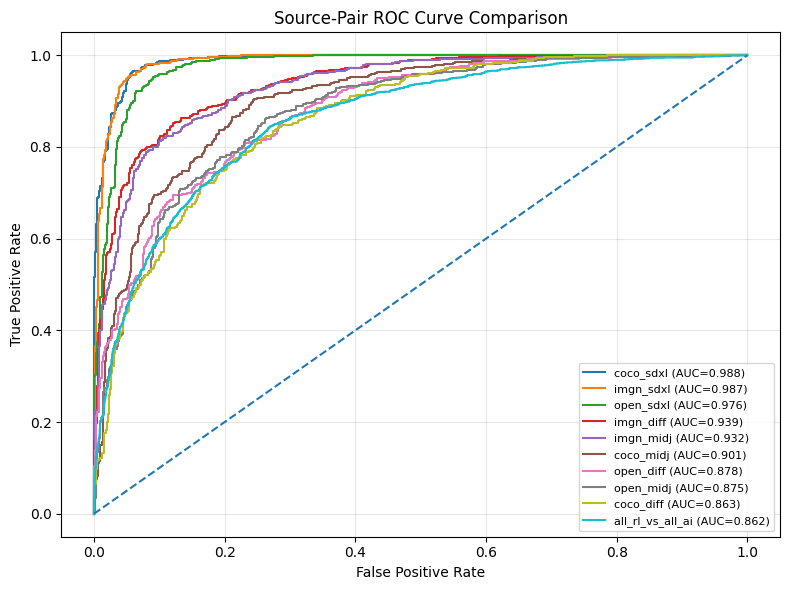

Source-pair ROC curve plot complete.


In [16]:
# ============================================
# Step 7: Plot Source-Pair ROC Curves
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import matplotlib.pyplot as plt

# -------------------------------------------------
# Verify source-pair results are available
# -------------------------------------------------
if source_pair_results_df.empty:
    raise ValueError("Source-pair results table is empty.")

# -------------------------------------------------
# Create ROC curve plot
# -------------------------------------------------
plt.figure(figsize=(8, 6))

for _, row in source_pair_results_df.iterrows():

    plt.plot(
        row["fpr"],
        row["tpr"],
        label=f"{row['experiment_id']} (AUC={row['roc_auc']:.3f})"
    )

# -------------------------------------------------
# Plot random classifier reference line
# -------------------------------------------------
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Source-Pair ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8, loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Source-pair ROC curve plot complete.")



### 🔷 Step 8 — Save Analysis Outputs

This step saves the source-pair analysis results and ROC curve plot to disk for later use in reports, tutorials, and further analysis.

* Saves the source-pair evaluation results table as a CSV file
* Saves the ROC curve comparison plot as an image file
* Stores outputs in the configured results directory
* Ensures all outputs are available for downstream use and documentation

---

In [17]:
# ============================================
# Step 8: Save Analysis Outputs
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import matplotlib.pyplot as plt

# -------------------------------------------------
# Define output file paths
# -------------------------------------------------
SOURCE_PAIR_RESULTS_FILENAME = "source_pair_results.csv"
SOURCE_PAIR_ROC_PLOT_FILENAME = "source_pair_roc_curves.png"

SOURCE_PAIR_RESULTS_PATH = RESULTS_DIR / SOURCE_PAIR_RESULTS_FILENAME
SOURCE_PAIR_ROC_PLOT_PATH = RESULTS_DIR / SOURCE_PAIR_ROC_PLOT_FILENAME

# -------------------------------------------------
# Save results table (exclude array columns)
# -------------------------------------------------
results_to_save = source_pair_results_df.drop(
    columns=["fpr", "tpr", "thresholds"],
    errors="ignore"
)

results_to_save.to_csv(SOURCE_PAIR_RESULTS_PATH, index=False)

print(f"Results table saved to: {SOURCE_PAIR_RESULTS_PATH}")

# -------------------------------------------------
# Recreate and save ROC curve plot
# -------------------------------------------------
plt.figure(figsize=(8, 6))

for _, row in source_pair_results_df.iterrows():
    plt.plot(
        row["fpr"],
        row["tpr"],
        label=f"{row['experiment_id']} (AUC={row['roc_auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Source-Pair ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8, loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SOURCE_PAIR_ROC_PLOT_PATH, dpi=300)
plt.close()

print(f"ROC curve plot saved to: {SOURCE_PAIR_ROC_PLOT_PATH}")

print("Analysis outputs saved successfully.")



Results table saved to: /content/dip-ai-image-detection/metadata/results/source_pair_results.csv
ROC curve plot saved to: /content/dip-ai-image-detection/metadata/results/source_pair_roc_curves.png
Analysis outputs saved successfully.
